# Understand stellar fiber contaminants

In [1]:
import numpy as np

from astropy import units, coordinates
from scipy.stats import binned_statistic_2d, binned_statistic_dd
from astropy.table import Table
import os

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use('figure_style.mplstyle')

In [230]:
def calculate_total_mag(mags):
    if len(mags)==0:
        return np.nan
    elif len(mags)==1:
        return float(mags[0])
    else:
        #Use the first one as the reference, why not
        magtot = mags[0] - 2.5*np.log10(np.sum(np.array([10**(-0.4*(mags[i]-mags[0])) for i in range(len(mags))])))
        return float(magtot)

## Read in data

In [134]:
file_dir = '/Users/gailzasowski/Dropbox/Documents/science/synthpop/outputfiles/hge_bkgd_tests/'
files = [
    f.name 
    for f in os.scandir(file_dir)
    if f.name.endswith(".fits") and f.name.startswith("hge_bkgd_tests_")
]
print(files)

['hge_bkgd_tests_l-20.0_b0.5_scaled20.000.fits', 'hge_bkgd_tests_l-20.0_b1.5_scaled20.000.fits', 'hge_bkgd_tests_l-10.0_b1.5_scaled20.000.fits', 'hge_bkgd_tests_l-10.0_b0.5_scaled20.000.fits', 'hge_bkgd_tests_l0.0_b0.5_scaled20.000.fits', 'hge_bkgd_tests_l0.0_b1.5_scaled20.000.fits']


In [288]:
dat = Table.read(file_dir + files[1])
# Convert (l,b,dist) to Galactic (R,Z,phi)
all_coords = coordinates.SkyCoord(
    frame="galactic",
    l=dat["l"],
    b=dat["b"],
    distance=dat["Dist"],
    unit=(units.deg, units.deg, units.kpc),
)

all_coords = all_coords.transform_to(coordinates.Galactocentric)
gal_x = all_coords.x / units.kpc
gal_y = all_coords.y / units.kpc
gal_z = all_coords.z / units.kpc
gal_r = np.sqrt(((all_coords.x) ** 2.0) + ((all_coords.y) ** 2.0)) / units.kpc

aj = 3.02*dat['A_Ks']
ah = 1.73*dat['A_Ks']
ak = dat['A_Ks']
jk = np.subtract(dat['2MASS_J'], dat['2MASS_Ks'])
jk0 = jk - (np.subtract(aj, ak))
h0 = dat['2MASS_H'] - ah

#Flip lons that straddle l=0
neg = (dat['l'] > 180.)
if np.nansum(neg) > 0:
    dat['l'][neg] = -1.*(360.-dat['l'][neg])

In [289]:
print(dat.colnames)
print('{} points'.format(len(dat['pop'])))
print('min mass = {:.2f} Msun'.format(min(dat['iMass'])))

['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist', 'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR', 'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius', 'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J', '2MASS_H', '2MASS_Ks', 'IRAC_3.6', 'IRAC_4.5']
929698 points
min mass = 0.10 Msun


In [290]:
# Possible targets: 
gaia_g_max = 19.0
gaia_xp_max = 17.5
h_min = 12.5
h_max = 16.5
jk0_min = 0.75
#assume we can remove close/G-bright things
can_remove = np.logical_or.reduce([np.logical_and.reduce([dat['Dist'] < 10.0,
                                                          dat['Gaia_G_EDR3'] < gaia_g_max]),
                                   np.logical_and.reduce([dat['logg'] > 2.0,
                                                          dat['Gaia_G_EDR3'] < gaia_xp_max])])
targ = np.logical_and.reduce([~can_remove,
                              dat['2MASS_H'] < h_max, 
                              dat['2MASS_H'] > h_min,
                              jk0 > jk0_min])
contam = np.logical_and.reduce([~can_remove,
                                dat['2MASS_H'] > h_max])
                                
print('{} stars to remove, {} targets, {} faint contaminants'.format(np.nansum(can_remove), 
                                                                                   np.nansum(targ), 
                                                                                   np.nansum(contam)))


5530 stars to remove, 33092 targets, 867725 faint contaminants


In [291]:
#Make binned images
xr = [-9,15]
n_xbins = 40

yr = [-10,10]
n_ybins = n_xbins

zr = [-2,2]
n_zbins = 20

rr = [0,12]
n_rbins = n_xbins

jkr = [0.5,5]
n_jkbins = 30

jk0r = jkr #[0,2.5]
n_jk0bins = 30

hr = [h_min,20]
n_hbins = 20

h0r = [10,20]
n_h0bins = 20

teffr = [3000,7000]
n_teffbins = 40

loggr = [0,5.5]
n_loggbins = 40

rvr = [-300,300]
n_rvbins = 20


#Targets
targ_xy, xe, ye, bn = binned_statistic_2d(gal_x[targ], gal_y[targ], 
                                          dat['l'][targ], statistic='count',
                                          range=[xr,yr], bins=[n_xbins,n_ybins])
targ_cmd, xe, ye, bn = binned_statistic_2d(jk[targ], dat['2MASS_H'][targ], 
                                           dat['l'][targ], statistic='count',
                                          range=[jkr,hr], bins=[n_jkbins,n_hbins])
targ_cmd0, xe, ye, bn = binned_statistic_2d(jk0[targ], dat['2MASS_H'][targ]-ah[targ], 
                                           dat['l'][targ], statistic='count',
                                          range=[jk0r,h0r], bins=[n_jk0bins,n_h0bins])
targ_hrd, xe, ye, bn = binned_statistic_2d(10.**dat['logTeff'][targ], dat['logg'][targ], 
                                           dat['l'][targ], statistic='count',
                                          range=[teffr,loggr], bins=[n_teffbins,n_loggbins])
targ_kin, xe, ye, bn = binned_statistic_2d(dat['2MASS_H'][targ], dat['vr_bc'][targ], 
                                           dat['l'][targ], statistic='count',
                                          range=[hr, rvr], bins=[n_hbins,n_rvbins])

#Contaminants
contam_xy, xe, ye, bn = binned_statistic_2d(gal_x[contam], gal_y[contam], 
                                            dat['l'][contam], statistic='count',
                                            range=[xr,yr], bins=[n_xbins,n_ybins])
contam_cmd, xe, ye, bn = binned_statistic_2d(jk[contam], dat['2MASS_H'][contam], 
                                             dat['l'][contam], statistic='count',
                                             range=[jkr,hr], bins=[n_jkbins,n_hbins])
contam_cmd0, xe, ye, bn = binned_statistic_2d(jk0[contam], dat['2MASS_H'][contam]-ah[contam], 
                                           dat['l'][contam], statistic='count',
                                          range=[jk0r,h0r], bins=[n_jk0bins,n_h0bins])
contam_hrd, xe, ye, bn = binned_statistic_2d(10.**dat['logTeff'][contam], dat['logg'][contam], 
                                           dat['l'][contam], statistic='count',
                                          range=[teffr,loggr], bins=[n_teffbins,n_loggbins])
contam_kin, xe, ye, bn = binned_statistic_2d(dat['2MASS_H'][contam], dat['vr_bc'][contam], 
                                             dat['l'][contam], statistic='count',
                                             range=[hr, rvr], bins=[n_hbins,n_rvbins])


/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_83730/4072512454.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(targ_xy.T), aspect='auto', origin='lower',
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_83730/4072512454.py:15: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(contam_xy.T), aspect='auto', origin='lower',
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_83730/4072512454.py:26: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(targ_cmd.T), aspect='auto', origin='lower',
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_83730/4072512454.py:35: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(contam_cmd.T), aspect='auto', origin='lower',
/var/folders/g9/0lndh9c56xz5yrl_6t6z1wn40000gn/T/ipykernel_83730/4072512454.py:45: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(targ_cmd0.T), aspect='auto', origin='l

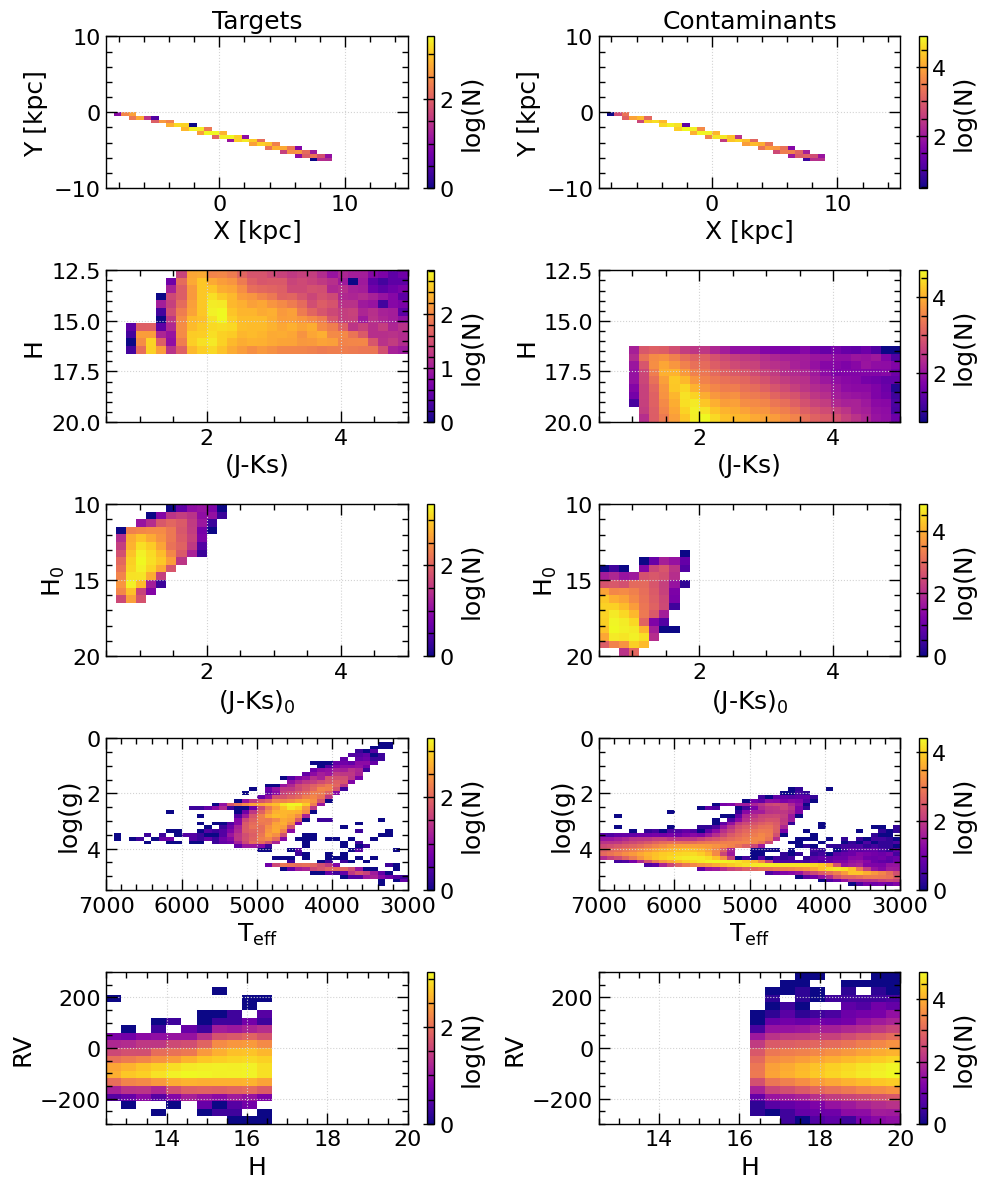

In [292]:
fig = plt.figure(figsize=(10,12))

#XY
ax = plt.subplot(521)
plt.imshow(np.log10(targ_xy.T), aspect='auto', origin='lower',
           extent=[min(xr),max(xr),min(yr),max(yr)])
plt.colorbar(label='log(N)')
plt.xlim(xr)
plt.ylim(yr)
plt.xlabel('X [kpc]')
plt.ylabel('Y [kpc]')
plt.title('Targets')

ax = plt.subplot(522)
plt.imshow(np.log10(contam_xy.T), aspect='auto', origin='lower',
           extent=[min(xr),max(xr),min(yr),max(yr)])
plt.colorbar(label='log(N)')
plt.xlim(xr)
plt.ylim(yr)
plt.xlabel('X [kpc]')
plt.ylabel('Y [kpc]')
plt.title('Contaminants')

#CMD
ax = plt.subplot(523)
plt.imshow(np.log10(targ_cmd.T), aspect='auto', origin='lower',
           extent=[min(jkr),max(jkr),min(hr),max(hr)])
plt.colorbar(label='log(N)')
plt.xlim(jkr)
plt.ylim(np.flip(hr))
plt.xlabel(r'(J-Ks)')
plt.ylabel('H')

ax = plt.subplot(524)
plt.imshow(np.log10(contam_cmd.T), aspect='auto', origin='lower',
           extent=[min(jkr),max(jkr),min(hr),max(hr)])
plt.colorbar(label='log(N)')
plt.xlim(jkr)
plt.ylim(np.flip(hr))
plt.xlabel(r'(J-Ks)')
plt.ylabel('H')

#CMD_0
ax = plt.subplot(525)
plt.imshow(np.log10(targ_cmd0.T), aspect='auto', origin='lower',
           extent=[min(jk0r),max(jk0r),min(h0r),max(h0r)])
plt.colorbar(label='log(N)')
plt.xlim(jk0r)
plt.ylim(np.flip(h0r))
plt.xlabel(r'(J-Ks)$_0$')
plt.ylabel(r'H$_0$')

ax = plt.subplot(526)
plt.imshow(np.log10(contam_cmd0.T), aspect='auto', origin='lower',
           extent=[min(jk0r),max(jk0r),min(h0r),max(h0r)])
plt.colorbar(label='log(N)')
plt.xlim(jk0r)
plt.ylim(np.flip(h0r))
plt.xlabel(r'(J-Ks)$_0$')
plt.ylabel(r'H$_0$')

#HRD
ax = plt.subplot(527)
plt.imshow(np.log10(targ_hrd.T), aspect='auto', origin='lower',
           extent=[min(teffr),max(teffr),min(loggr),max(loggr)])
plt.colorbar(label='log(N)')
plt.xlim(np.flip(teffr))
plt.ylim(np.flip(loggr))
plt.xlabel(r'T$_{\rm eff}$')
plt.ylabel('log(g)')

ax = plt.subplot(528)
plt.imshow(np.log10(contam_hrd.T), aspect='auto', origin='lower',
           extent=[min(teffr),max(teffr),min(loggr),max(loggr)])
plt.colorbar(label='log(N)')
plt.xlim(np.flip(teffr))
plt.ylim(np.flip(loggr))
plt.xlabel(r'T$_{\rm eff}$')
plt.ylabel('log(g)')

#Kinematics
ax = plt.subplot(529)
plt.imshow(np.log10(targ_kin.T), aspect='auto', origin='lower',
           extent=[min(hr),max(hr),min(rvr),max(rvr)])
plt.colorbar(label='log(N)')
plt.ylim(rvr)
plt.xlim(hr)
plt.xlabel('H')
plt.ylabel('RV')

ax = plt.subplot(5,2,10)
plt.imshow(np.log10(contam_kin.T), aspect='auto', origin='lower',
           extent=[min(hr),max(hr),min(rvr),max(rvr)])
plt.colorbar(label='log(N)')
plt.ylim(rvr)
plt.xlim(hr)
plt.xlabel('H')
plt.ylabel('RV')

fig.tight_layout()

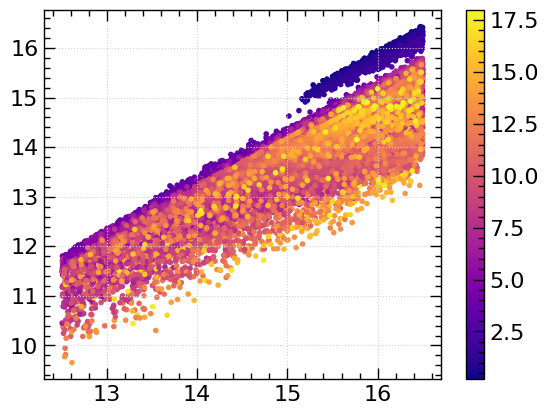

In [293]:
show = contam
#plt.scatter(dat['Dist'][show], np.subtract(dat['Gaia_G_EDR3'][show],dat['2MASS_H'][show]), 
#            c=dat['logg'][show],
#            marker='.') #, vmin=gaia_g_max, vmax=21)
#plt.colorbar()
#plt.xlim([0,15])
#plt.ylim([18,22])

plt.scatter(dat['2MASS_H'][targ], np.subtract(dat['2MASS_H'],ah)[targ], 
            c=dat['Dist'][targ], marker='.')
plt.colorbar()

#ak_rjce = 0.918*(np.subtract(dat['2MASS_H'],dat['IRAC_4.5'])-0.08)
#plt.plot(np.subtract(ak,ak_rjce), dat['logg'], '.')

In [294]:
#Bin targets and contaminants in 2" pixels
#For each pixel with 1 target, calculate the flux ratio between it and all of the contaminants

delta_lon = 6/3600. #degrees
lonr = [min(dat['l']),max(dat['l'])]
n_lonbins = round(abs(lonr[1]-lonr[0])/delta_lon)
delta_lat = delta_lon
latr = [min(dat['b']),max(dat['b'])]
n_latbins = round(abs(latr[1]-latr[0])/delta_lat)

print('{}x{} bins, {:.1f} arcsec per side'.format(n_lonbins,n_latbins,3600.*delta_lon))

target_counts = binned_statistic_2d(dat['l'][targ], dat['b'][targ], 
                                    dat['l'][targ], statistic='count',
                                    range=[lonr,latr], bins=[n_lonbins,n_latbins], expand_binnumbers=True)
target_magtot = binned_statistic_2d(dat['l'][targ], dat['b'][targ], 
                                    dat['2MASS_H'][targ], statistic=calculate_total_mag,
                                    range=[lonr,latr], bins=[n_lonbins,n_latbins], expand_binnumbers=True)
contam_counts = binned_statistic_2d(dat['l'][contam], dat['b'][contam], 
                                    dat['l'][contam], statistic='count',
                                    range=[lonr,latr], bins=[n_lonbins,n_latbins], expand_binnumbers=True)
contam_magtot = binned_statistic_2d(dat['l'][contam], dat['b'][contam], 
                                    dat['2MASS_H'][contam], statistic=calculate_total_mag,
                                    range=[lonr,latr], bins=[n_lonbins,n_latbins], expand_binnumbers=True)

958x957 bins, 6.0 arcsec per side


In [295]:
#%debug

In [296]:
print(np.min(target_counts.statistic.flatten()),np.max(target_counts.statistic.flatten()))
print(np.min(contam_counts.statistic.flatten()),np.max(contam_counts.statistic.flatten()))

0.0 3.0
0.0 10.0


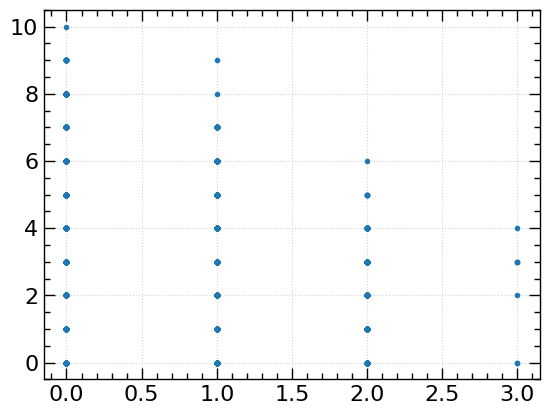

In [297]:
plt.plot(target_counts.statistic.flatten(),contam_counts.statistic.flatten(),'.')

In [298]:
#We're only going to target stars that have 1 "target" star per fiber aperture
single_target = np.where(target_counts.statistic == 1)

##For each of these stars, get the mags of the contaminant stars in the same pixel
#counts = []
#for i in range(np.shape(to_check)[0]):
#    ind1 = (target_counts.binnumber[0,:] == to_check[0][i])
#    ind2 = (target_counts.binnumber[0,:] == to_check[1][i])
#    counts.append(target_counts.statistic[np.logical_and.reduce([ind1,ind2])])

flux_ratio = np.full(np.shape(target_magtot.statistic), fill_value=np.nan)
flux_ratio[single_target] = 10.**(-0.4*(np.subtract(target_magtot.statistic[single_target],contam_magtot.statistic[single_target])))


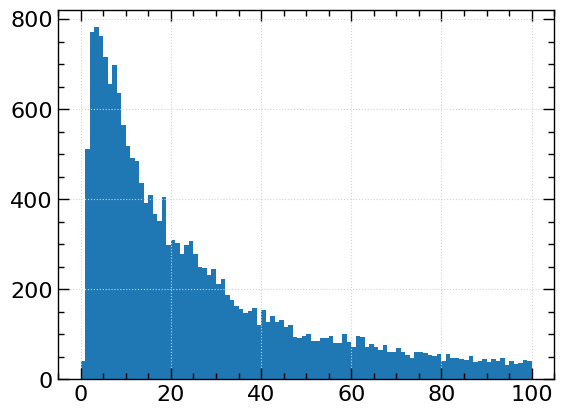

In [299]:
#plt.imshow(np.log10(contam_counts.statistic.T))
#plt.imshow(flux_ratio.T)
#plt.colorbar()
_=plt.hist(flux_ratio.flatten(), range=[0,100], bins=100)